# Metamodele Processus Gaussien — MAELIA (interpolation)

Processus Gaussien avec noyau **Matern 5/2 + bruit blanc** (sklearn). Adapte a l'**interpolation** : donne une incertitude de prediction et est exact aux points d'entrainement (bruit -> 0).

Scalabilite : le GP est entraine sur un **sous-echantillon stratifie** (~1 000 points, 50 sim x 20 parcelles) pour rester dans O(n^3). La validation croisee est effectuee sur ce sous-echantillon.

Indices de Sobol estimes par le **schema de Saltelli** applique au metamodele entraine.

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

XML_DIR = Path('/tmp/maelia_smt_xml')
OUTPUT_COLS   = ['N_lixi', 'dCorg', 'rdt']
OUTPUT_LABELS = ['N lixivie (kgN/ha)', 'dC organique (kgC/ha)', 'Rendement (t/ha)']
OUTPUT_COLORS = ['#e74c3c', '#3498db', '#2ecc71']
SOL_TYPES  = ['18960_27491', '330104_330367_1', '330151_330489_1']
ZONE_MAP   = {'beauce': 0, 'oceanique': 1, 'sudouest': 2}
ZONE_NAMES = {0: 'beauce', 1: 'oceanique', 2: 'sudouest'}
ZONE_COLORS = {0: '#3498db', 1: '#e67e22', 2: '#2ecc71'}
N_FOLDS_CV  = 5
RANDOM_SEED = 42
N_SIM_SUB   = 50   # simulations pour le sous-echantillon
N_PLOTS_SUB = 20   # parcelles par simulation

INPUT_LABELS = [
    'Nb apports fertilisation', 'Preparation sol (oui/non)', 'Nb operations prepa sol',
    'Type prepa sol 1', 'Type prepa sol 2', 'Nb produits engrais F1',
    'Type engrais F1-1', 'Type engrais F1-2', 'Nb produits engrais F2',
    'Type engrais F2-1', 'Type engrais F2-2', 'Nb produits engrais F3',
    'Type engrais F3-1', 'Type engrais F3-2', 'Jour de semis (j/an)',
    'Jours avant prepa sol', 'Jours semis -> F1', 'Jours F1 -> F2',
    'Jours F2 -> F3', 'Jours op. -> recolte', 'Dose F1-1 (kgN/ha)',
    'Dose F1-2 (kgN/ha)', 'Dose F2-1 (kgN/ha)', 'Dose F2-2 (kgN/ha)',
    'Dose F3-1 (kgN/ha)', 'Dose F3-2 (kgN/ha)',
    'Zone beauce (indicatrice)', 'Zone oceanique (indicatrice)',
    'Sol A - 18960_27491', 'Sol B - 330104_330367_1',
]
N_INPUTS = len(INPUT_LABELS)
VAR_BOUNDS = [
    (0,3),(0,1),(0,1),(0,3),(0,3),(0,1),(0,3),(0,3),(0,1),(0,3),(0,3),
    (0,1),(0,3),(0,3),(260,320),(1,30),(100,250),(1,60),(1,60),(1,250),
    (10,100),(10,100),(10,100),(10,100),(10,100),(10,100),
    (0,1),(0,1),(0,1),(0,1),
]
print(f'sklearn GP  |  {N_INPUTS} inputs  |  sous-echantillon : {N_SIM_SUB} sim x {N_PLOTS_SUB} parcelles = {N_SIM_SUB*N_PLOTS_SUB} points')

sklearn GP  |  30 inputs  |  sous-echantillon : 50 sim x 20 parcelles = 1000 points


## 1. Chargement & construction de X, Y

In [2]:
xt          = np.load(XML_DIR / 'doe_xt.npy')
is_acting_t = np.load(XML_DIR / 'doe_is_acting.npy')
df_mm       = pd.read_csv(XML_DIR / 'dataset_metamodel.csv')
N_DOE       = xt.shape[0]

rows_X, rows_Y, row_sim_idx, row_zone_id = [], [], [], []
for _, row in df_mm.iterrows():
    idx  = int(row['sim_idx'])
    zone = row['zone']
    if zone not in ZONE_MAP:
        continue
    sol   = row.get('sol_type', None)
    x_smt = xt[idx].astype(float).copy()
    x_smt[~is_acting_t[idx]] = np.nan
    zo    = ZONE_MAP[zone]
    rows_X.append(np.concatenate([
        x_smt,
        [1. if zo==0 else 0., 1. if zo==1 else 0.,
         1. if sol==SOL_TYPES[0] else 0., 1. if sol==SOL_TYPES[1] else 0.]
    ]))
    rows_Y.append([row.get(c, np.nan) for c in OUTPUT_COLS])
    row_sim_idx.append(idx)
    row_zone_id.append(zo)

X_raw    = np.array(rows_X)
Y_raw    = np.array(rows_Y)
SIM_IDX  = np.array(row_sim_idx)
ZONE_IDS = np.array(row_zone_id)

# Imputation
X_imp     = X_raw.copy()
imp_means = np.nanmean(X_imp, axis=0)
for j in range(N_INPUTS):
    mask = np.isnan(X_imp[:, j])
    X_imp[mask, j] = imp_means[j]

print(f'X : {X_imp.shape}  Y : {Y_raw.shape}  ({N_DOE} simulations x {len(df_mm)//N_DOE} parcelles)')

X : (13000, 30)  Y : (13000, 3)  (100 simulations x 130 parcelles)


## 2. Sous-echantillon stratifie

On retient `N_SIM_SUB` simulations choisies aleatoirement, puis `N_PLOTS_SUB` parcelles par simulation. Cela garantit la diversite climatique et pedologique dans le sous-echantillon.

In [3]:
rng = np.random.default_rng(RANDOM_SEED)
unique_sims   = np.unique(SIM_IDX)
chosen_sims   = rng.choice(unique_sims, size=N_SIM_SUB, replace=False)

sub_idx = []
for sim in chosen_sims:
    candidates = np.where(SIM_IDX == sim)[0]
    chosen     = rng.choice(candidates, size=min(N_PLOTS_SUB, len(candidates)), replace=False)
    sub_idx.extend(chosen.tolist())
sub_idx = np.array(sub_idx)

X_sub    = X_imp[sub_idx]
Y_sub    = Y_raw[sub_idx]
SIM_sub  = SIM_IDX[sub_idx]
ZONE_sub = ZONE_IDS[sub_idx]

# Remaining points for out-of-sample test
all_idx      = np.arange(len(X_imp))
test_idx     = np.setdiff1d(all_idx, sub_idx)
X_test_full  = X_imp[test_idx]
Y_test_full  = Y_raw[test_idx]
ZONE_test    = ZONE_IDS[test_idx]

print(f'Sous-echantillon entrainement : {len(sub_idx)} points ({N_SIM_SUB} sim x {N_PLOTS_SUB} parcelles)')
print(f'Points de test (hors-sous-echantillon) : {len(test_idx)}')

Sous-echantillon entrainement : 1000 points (50 sim x 20 parcelles)
Points de test (hors-sous-echantillon) : 12000


## 3. Entrainement GP + CV stratifiee sur le sous-echantillon

In [4]:
def make_gp():
    kernel = ConstantKernel(1.0) * Matern(nu=2.5) + WhiteKernel(noise_level=0.1)
    return GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3,
                                    normalize_y=True, random_state=RANDOM_SEED)

kf = KFold(n_splits=N_FOLDS_CV, shuffle=True, random_state=RANDOM_SEED)

def stratified_cv_q2(X, y, sim_arr):
    unique_sims = np.unique(sim_arr)
    yt_all, yp_all = [], []
    for tr_idx, te_idx in kf.split(unique_sims):
        tr_sims = set(unique_sims[tr_idx])
        te_sims = set(unique_sims[te_idx])
        tr = np.array([i for i, s in enumerate(sim_arr) if s in tr_sims])
        te = np.array([i for i, s in enumerate(sim_arr) if s in te_sims])
        scaler = StandardScaler().fit(X[tr])
        gp = make_gp()
        gp.fit(scaler.transform(X[tr]), y[tr])
        yt_all.extend(y[te])
        yp_all.extend(gp.predict(scaler.transform(X[te])))
    return r2_score(yt_all, yp_all)

models   = {}
scalers  = {}
metrics  = {}
valid_masks_sub = {}

for col in OUTPUT_COLS:
    k    = OUTPUT_COLS.index(col)
    y    = Y_sub[:, k]
    mask = ~np.isnan(y)
    valid_masks_sub[col] = mask
    sc   = StandardScaler().fit(X_sub[mask])
    gp   = make_gp()
    gp.fit(sc.transform(X_sub[mask]), y[mask])
    scalers[col] = sc
    models[col]  = gp
    r2_tr = r2_score(y[mask], gp.predict(sc.transform(X_sub[mask])))
    q2    = stratified_cv_q2(X_sub[mask], y[mask], SIM_sub[mask])
    metrics[col] = dict(R2_train=r2_tr, Q2_strat=q2, n=int(mask.sum()))
    qlt = 'Bon' if q2 > 0.7 else 'Acceptable' if q2 > 0.4 else 'Faible'
    print(f'{col:<8}  R2={r2_tr:.3f}  Q2_strat={q2:.3f}  -> {qlt}')

N_lixi    R2=0.943  Q2_strat=0.663  -> Acceptable
dCorg     R2=0.983  Q2_strat=0.073  -> Faible
rdt       R2=0.755  Q2_strat=-0.111  -> Faible


## 4. Graphique de validation (predit vs observe)

Deux types de points : **entrainement** (sous-echantillon, cercles pleins) et **test hors-echantillon** (croix).

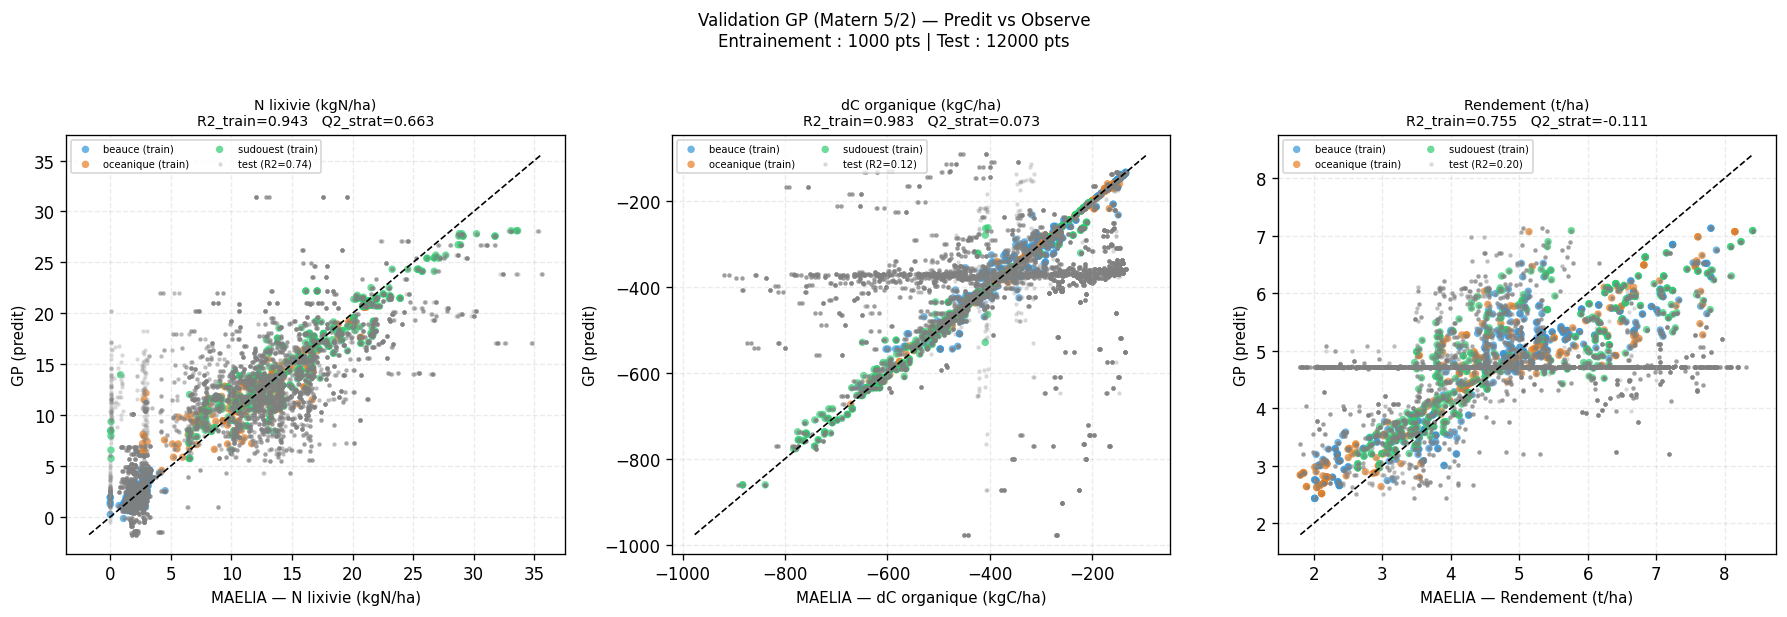

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, lbl, color in zip(axes, OUTPUT_COLS, OUTPUT_LABELS, OUTPUT_COLORS):
    k      = OUTPUT_COLS.index(col)
    mask_s = valid_masks_sub[col]
    gp     = models[col]
    sc     = scalers[col]
    m      = metrics[col]

    # Points d'entrainement
    y_tr = Y_sub[mask_s, k]
    y_pr = gp.predict(sc.transform(X_sub[mask_s]))
    for z_id in [0, 1, 2]:
        zm = (ZONE_sub[mask_s] == z_id)
        ax.scatter(y_tr[zm], y_pr[zm], c=ZONE_COLORS[z_id], s=20,
                   alpha=0.7, edgecolors='none', label=f'{ZONE_NAMES[z_id]} (train)')

    # Points de test hors-echantillon
    mask_te = ~np.isnan(Y_test_full[:, k])
    if mask_te.sum() > 0:
        y_te_true = Y_test_full[mask_te, k]
        y_te_pred = gp.predict(sc.transform(X_test_full[mask_te]))
        r2_te = r2_score(y_te_true, y_te_pred)
        ax.scatter(y_te_true, y_te_pred, c='gray', s=8, alpha=0.3,
                   marker='+', label=f'test (R2={r2_te:.2f})')

    all_true = np.concatenate([y_tr, y_te_true if mask_te.sum() > 0 else []])
    all_pred = np.concatenate([y_pr, y_te_pred if mask_te.sum() > 0 else []])
    lims = [min(all_true.min(), all_pred.min()), max(all_true.max(), all_pred.max())]
    ax.plot(lims, lims, 'k--', lw=1)
    ax.set_xlabel(f'MAELIA — {lbl}', fontsize=9)
    ax.set_ylabel('GP (predit)', fontsize=9)
    ax.set_title(f'{lbl}\nR2_train={m["R2_train"]:.3f}   Q2_strat={m["Q2_strat"]:.3f}', fontsize=8.5)
    ax.legend(fontsize=6, loc='upper left', ncol=2)
    ax.grid(alpha=0.25, linestyle='--')

fig.suptitle(f'Validation GP (Matern 5/2) — Predit vs Observe\nEntrainement : {len(sub_idx)} pts | Test : {len(test_idx)} pts',
             fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig(XML_DIR / 'gp_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Indices de Sobol (schema de Saltelli)

In [8]:
def compute_sobol_s1(predict_fn, bounds, N=2048, seed=42):
    """Estimateur de Saltelli/Jansen pour S1."""
    rng = np.random.default_rng(seed)
    d   = len(bounds)
    lo  = np.array([b[0] for b in bounds])
    hi  = np.array([b[1] for b in bounds])
    A   = lo + rng.random((N, d)) * (hi - lo)
    B   = lo + rng.random((N, d)) * (hi - lo)
    fA  = predict_fn(A).ravel()
    fB  = predict_fn(B).ravel()
    var_Y = np.var(np.concatenate([fA, fB]))
    # En haute dimension, le GP peut revenir au prior moyen pour des echantillons OOD.
    # Dans ce cas var_Y ~ 0 ET mean((fB-fABi)^2) ~ 0, mais leur ratio 0/1e-12
    # donne artificiellement S1=1 pour chaque variable (somme = 30).
    # Si le CV est < 0.1 %, le modele n'est pas discriminant sur ces echantillons.
    mean_sq = np.mean(fA) ** 2
    if var_Y < 1e-6 * (mean_sq + 1e-8):
        print(f'  Attention : var_Y={var_Y:.2e} (GP au prior sur ces echantillons) — S1 mis a zero.')
        return np.zeros(d)
    S1 = np.zeros(d)
    for i in range(d):
        AB_i = A.copy(); AB_i[:, i] = B[:, i]
        fABi = predict_fn(AB_i).ravel()
        S1[i] = max(0., 1. - 0.5 * np.mean((fB - fABi)**2) / var_Y)
    return S1

sobol_S1 = {}
for col in OUTPUT_COLS:
    sc = scalers[col]
    gp = models[col]
    fn = lambda X, sc=sc, gp=gp: gp.predict(sc.transform(X))
    sobol_S1[col] = compute_sobol_s1(fn, VAR_BOUNDS, N=2048)
    print(f'{col}  Somme S1 = {sobol_S1[col].sum():.3f}')


N_lixi  Somme S1 = 0.668
dCorg  Somme S1 = 0.365
  Attention : var_Y=3.16e-30 (GP au prior sur ces echantillons) — S1 mis a zero.
rdt  Somme S1 = 0.000


## 6. Visualisation des indices de Sobol

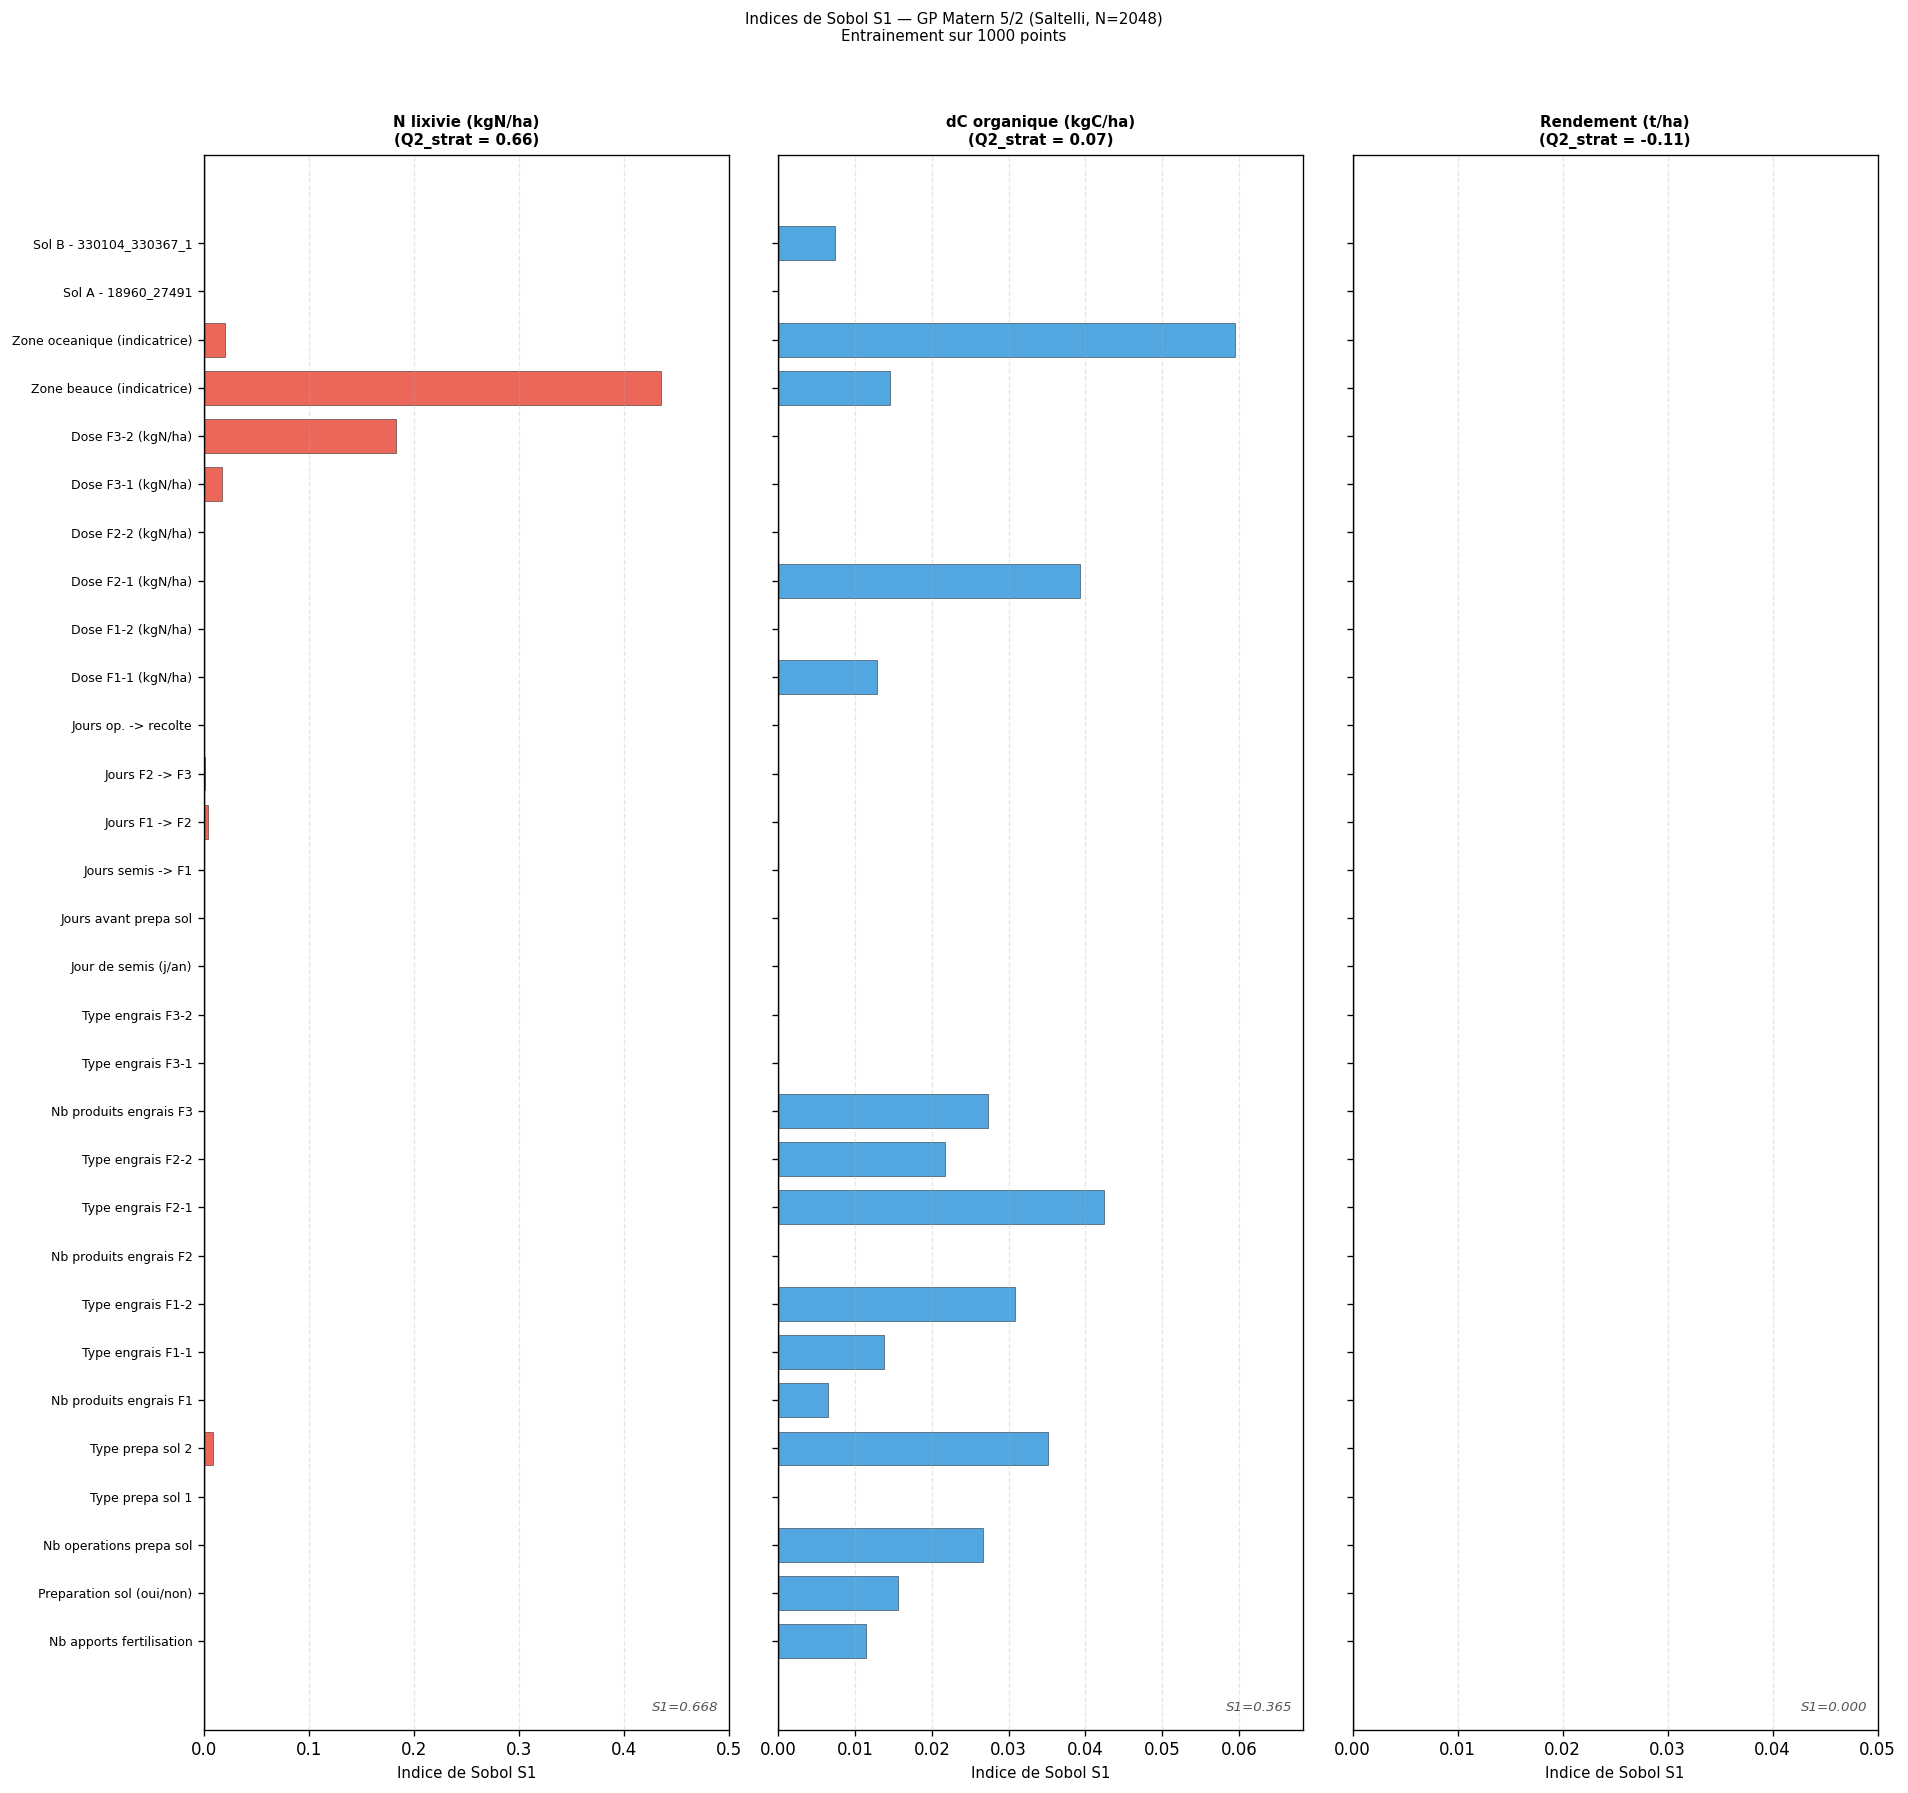

Figures -> /tmp/maelia_smt_xml/gp_validation.png  et  gp_sobol.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, max(8, 0.42 * N_INPUTS + 2)), sharey=True)
y_pos = np.arange(N_INPUTS)

for ax, col, lbl, color in zip(axes, OUTPUT_COLS, OUTPUT_LABELS, OUTPUT_COLORS):
    s1 = sobol_S1[col]
    m  = metrics[col]
    ax.barh(y_pos, s1, color=color, alpha=0.85, edgecolor='k', linewidth=0.3, height=0.7)
    ax.set_xlim(0, max(s1.max() * 1.15, 0.05))
    ax.set_xlabel('Indice de Sobol S1', fontsize=9)
    ax.set_title(f'{lbl}\n(Q2_strat = {m["Q2_strat"]:.2f})', fontsize=9, fontweight='bold')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(INPUT_LABELS, fontsize=7.5)
    ax.axvline(0, color='k', lw=0.8)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.text(0.98, 0.01, f'S1={s1.sum():.3f}', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=8, color='#555', style='italic')

fig.suptitle(f'Indices de Sobol S1 — GP Matern 5/2 (Saltelli, N=2048)\nEntrainement sur {len(sub_idx)} points',
             fontsize=9, y=1.02)
plt.tight_layout()
plt.savefig(XML_DIR / 'gp_sobol.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figures -> {XML_DIR}/gp_validation.png  et  gp_sobol.png')